
### identify the node (env/node/rssi)

two dataset strategy:

a. data from all env -> into a dataset and split to train 0.75/test 0.25

b. data from 

- 4 env (0, 1, 3, 4) -> for train 
- 1 env -> test (2)


500 seq length as frame

model: ResNet

overlapping: 40%

report:

model.summary() 

hyper parameter (overlapping / learning rate = 0.001)

epoch 20

In [332]:
# 📓 Jupyter Notebook: Preprocess e1-n0 dataset

import pandas as pd
import numpy as np

# === Step 1: Load CSV ===
df = pd.read_csv("./env/e4-garden.csv")  # your dataset path here

# === Step 2: time series sorting ===
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts')

# === Step 3: set environment ===
df['env'] = 1

# === Step 4: filter for e1-n0 ===
df_n0 = df[df['device'] == 'RIOT-BLE-0'].copy()

# === Step 5: diff ===
df_n0['rssi_diff'] = df_n0['rssi'].diff()

# === Step 6: normalization (min-max) ===
y_min = df_n0['rssi_diff'].min()
y_max = df_n0['rssi_diff'].max()
df_n0['rssi_norm'] = (df_n0['rssi_diff'] - y_min) / (y_max - y_min)

# === Step 7: create timeslot（100 packets）===
# time series sorting
df_n0 = df_n0.sort_values('ts').reset_index(drop=True)
# 100 packets per timeslot
WINDOW_SIZE = 100
df_n0['timeslot'] = df_n0.index // WINDOW_SIZE
# === Step 8: unify column names ===
df_n0['node'] = 'n0'
df_n0_final = df_n0[['timeslot', 'env', 'node', 'rssi_norm']].rename(columns={'rssi_norm': 'rssi'})

# === Step 9: display results ===
df_n0_final.head(101)

,timeslot,env,node,rssi
0,0,1,n0,NaN
1,0,1,n0,0.666667
2,0,1,n0,0.481481
3,0,1,n0,0.592593
4,0,1,n0,0.370370
...,...,...,...,...
96,0,1,n0,0.518519
97,0,1,n0,0.518519
98,0,1,n0,0.370370
99,0,1,n0,0.481481


In [333]:
import pandas as pd
import numpy as np

# parameters
WINDOW_SIZE = [100, 500, 1000] # 100/500/1000
STRIDE = [40, 50] # 40/50

# === file paths ===
env_files = [
    "env/e0-bridge.csv",
    "env/e1-lake.csv",
    "env/e2-forest.csv",
    "env/e3-river.csv",
    "env/e4-garden.csv"
]

# === device mapping ===
device_to_label = {
    "RIOT-BLE-0": 0,
    "RIOT-BLE-1": 1,
    "RIOT-BLE-2": 2,
    "RIOT-BLE-3": 3
}

def build_dataset(WINDOW_SIZE, STRIDE, env_files, device_to_label):
    # === store data ===
    X = []
    y = []
    env_ids = []

    # each environment
    for env_id, file in enumerate(env_files):

        df = pd.read_csv(file)

        # time series sorting
        df['ts'] = pd.to_datetime(df['ts'])
        df = df.sort_values('ts')

        # process each device
        for device, label in device_to_label.items():

            df_node = df[df['device'] == device].copy()
            if len(df_node) < WINDOW_SIZE:
                continue

            # === diff ===
            df_node['rssi_diff'] = df_node['rssi'].diff()
            
            # === drop NaN ===
            df_node = df_node.dropna(subset=['rssi_diff'])
            # === normalization (based on each node) ===
            y_min = df_node['rssi_diff'].min()
            y_max = df_node['rssi_diff'].max()

            if y_max - y_min == 0:
                continue

            df_node['rssi_norm'] = (df_node['rssi_diff'] - y_min) / (y_max - y_min)

            # === turn to numpy ===
            data = df_node['rssi_norm'].values

            # === create sequence ===
            for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
                seq = data[i:i+WINDOW_SIZE]

                X.append(seq)
                y.append(label)
                env_ids.append(env_id)

    # === turn to numpy ===
    X = np.array(X)
    y = np.array(y)
    env_ids = np.array(env_ids)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("env_ids shape:", env_ids.shape)
    print("\n")

    X = X.astype(np.float32)
    y = y.astype(np.int64)
    env_ids = env_ids.astype(np.int64)

    # PyTorch Conv1d input: (batch, channels, length)
    X_data = X[:, np.newaxis, :]  
    print("X_data shape:", X_data.shape)
    print("\n")
    return X_data, y, env_ids




In [334]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# =========================
# Version 1: random split
# =========================

def random_split(X_data, y):
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_data, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    # turn into PyTorch tensors
    X_train_r_tensor = torch.tensor(X_train_r, dtype=torch.float32)
    X_test_r_tensor  = torch.tensor(X_test_r, dtype=torch.float32)
    y_train_r_tensor = torch.tensor(y_train_r, dtype=torch.long)
    y_test_r_tensor  = torch.tensor(y_test_r, dtype=torch.long)

    # create Dataset and DataLoader
    train_dataset_r = TensorDataset(X_train_r_tensor, y_train_r_tensor)
    test_dataset_r  = TensorDataset(X_test_r_tensor, y_test_r_tensor)

    train_loader_r = DataLoader(train_dataset_r, batch_size=64, shuffle=True)
    test_loader_r  = DataLoader(test_dataset_r, batch_size=64, shuffle=False)

    print("X_train:", X_train_r_tensor.shape)
    print("X_test :", X_test_r_tensor.shape)
    print("y_train:", y_train_r_tensor.shape)
    print("y_test :", y_test_r_tensor.shape)
    print("\n")
    return train_loader_r, test_loader_r, X_test_r_tensor, y_test_r

In [335]:
# =========================
# Version 2: env-based split
# =========================

def env_based_split(X_data, y, env_ids):
    train_envs = [0, 1, 2, 3, 4]   
    test_env = 2           

    train_mask = np.isin(env_ids, train_envs)
    test_mask = (env_ids == test_env)

    X_train_e = X_data[train_mask]
    y_train_e = y[train_mask]

    X_test_e = X_data[test_mask]
    y_test_e = y[test_mask]

    # turn into PyTorch tensors
    X_train_e_tensor = torch.tensor(X_train_e, dtype=torch.float32)
    X_test_e_tensor  = torch.tensor(X_test_e, dtype=torch.float32)
    y_train_e_tensor = torch.tensor(y_train_e, dtype=torch.long)
    y_test_e_tensor  = torch.tensor(y_test_e, dtype=torch.long)

    # create Dataset and DataLoader
    train_dataset_e = TensorDataset(X_train_e_tensor, y_train_e_tensor)
    test_dataset_e  = TensorDataset(X_test_e_tensor, y_test_e_tensor)

    train_loader_e = DataLoader(train_dataset_e, batch_size=64, shuffle=True)
    test_loader_e  = DataLoader(test_dataset_e, batch_size=64, shuffle=False)

    print("Train envs:", train_envs)
    print("Test env :", test_env)
    print("\n")
    print("X_train:", X_train_e_tensor.shape)
    print("X_test :", X_test_e_tensor.shape)
    print("y_train:", y_train_e_tensor.shape)
    print("y_test :", y_test_e_tensor.shape)
    print("\n")
    return train_loader_e, test_loader_e, X_test_e_tensor, y_test_e

In [336]:
# === Residual Block ===
import torch.nn as nn

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels) # batch norm after conv1
        self.relu = nn.ReLU(inplace=True)

        # self.dropout = nn.Dropout(p=0.1) # dropout layer

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels) # batch norm after conv2

        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels: # projection shortcut if dimensions differ
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    
    # forward pass
    def forward(self, x):
        identity = self.shortcut(x)

        # conv1 -> bn -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # out = self.dropout(out) # dropout 

        # conv2 -> bn
        out = self.conv2(out)
        out = self.bn2(out)

        # add shortcut
        out += identity
        out = self.relu(out)

        return out

In [337]:
# === ResNet1D Model ===

class ResNet1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # initial convolution and pooling
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # layer1
        self.layer1 = nn.Sequential(
            ResidualBlock1D(16, 16, stride=1)
        )

        # layer2
        self.layer2 = nn.Sequential(
            ResidualBlock1D(16, 32, stride=2)
        )

        # layer3
        self.layer3 = nn.Sequential(
            ResidualBlock1D(32, 64, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        # self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)         # (B, 1, 100) -> (B, 16, 25)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)  # (B, 64, 1)
        x = x.squeeze(-1)        # (B, 64, 1) -> (B, 64)
        # x = self.dropout(x)      # dropout
        x = self.fc(x)           # (B, num_classes)
        return x

num_classes = len(np.unique(y))
model = ResNet1D(num_classes=num_classes)
print(model)

ResNet1D(
  (stem): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=T

In [338]:
# === Model Summary ===
from torchinfo import summary

summary(
    model,
    input_size=(64, 1, 500)  # (batch, channel, length)
)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet1D                                 [64, 4]                   --
├─Sequential: 1-1                        [64, 16, 125]             --
│    └─Conv1d: 2-1                       [64, 16, 250]             112
│    └─BatchNorm1d: 2-2                  [64, 16, 250]             32
│    └─ReLU: 2-3                         [64, 16, 250]             --
│    └─MaxPool1d: 2-4                    [64, 16, 125]             --
├─Sequential: 1-2                        [64, 16, 125]             --
│    └─ResidualBlock1D: 2-5              [64, 16, 125]             --
│    │    └─Sequential: 3-1              [64, 16, 125]             --
│    │    └─Conv1d: 3-2                  [64, 16, 125]             768
│    │    └─BatchNorm1d: 3-3             [64, 16, 125]             32
│    │    └─ReLU: 3-4                    [64, 16, 125]             --
│    │    └─Conv1d: 3-5                  [64, 16, 125]             768
│    │    └─

In [339]:
# =========================
# Step 3: training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [340]:
# =========================
# Step 4: training loop
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss / total, correct / total

In [341]:
# === Draw Plot ===

import matplotlib.pyplot as plt

def draw_plot(train_losses, test_losses, train_accs, test_accs):
    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(test_accs, label="Test Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()
    
    plt.show()

In [342]:
# =========================
# Step 5: run training
# =========================
num_epochs = 20


def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, device, num_epochs):
      # best_test_loss = float("inf")
      # best_state = None

      train_losses = []
      test_losses = []
      train_accs = []
      test_accs = []

      for epoch in range(num_epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            test_loss, test_acc = evaluate(model, test_loader, criterion, device)

            train_losses.append(train_loss)
            test_losses.append(test_loss)
            train_accs.append(train_acc)
            test_accs.append(test_acc)

            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
            
      draw_plot(train_losses, test_losses, train_accs, test_accs)

      # # save best model
      # if test_loss < best_test_loss:
      #     best_test_loss = test_loss
      #     best_state = model.state_dict()
      # model.load_state_dict(best_state)

In [343]:
# =========================
# Step 6: prediction example
# =========================

def predict(model, X_test_tensor, y_test, device):
    model.eval()

    with torch.no_grad():
        sample_x = X_test_tensor[:5].to(device)
        outputs = model(sample_x)
        preds = outputs.argmax(dim=1).cpu().numpy()

    print("Pred:", preds)
    print("True:", y_test[:5])

In [344]:
# =========================
# Step 7: confusion matrix
# =========================
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def compute_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    cm = confusion_matrix(all_true, all_preds)
    acc = accuracy_score(all_true, all_preds)

    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(all_true, all_preds))
    print(f"\nAccuracy: {acc:.4f}\n")

    return f"{acc:.4f}"



=== Version 1: random split ===


--- WINDOW_SIZE=100, STRIDE=40 ---

X shape: (8477, 100)
y shape: (8477,)
env_ids shape: (8477,)


X_data shape: (8477, 1, 100)


X_train: torch.Size([6357, 1, 100])
X_test : torch.Size([2120, 1, 100])
y_train: torch.Size([6357])
y_test : torch.Size([2120])


Epoch [1/20] Train Loss: 1.1158, Train Acc: 0.4708 | Test Loss: 1.0594, Test Acc: 0.5288
Epoch [2/20] Train Loss: 0.9460, Train Acc: 0.5773 | Test Loss: 0.9800, Test Acc: 0.5250
Epoch [3/20] Train Loss: 0.8628, Train Acc: 0.6190 | Test Loss: 0.7761, Test Acc: 0.6722
Epoch [4/20] Train Loss: 0.8273, Train Acc: 0.6395 | Test Loss: 0.8729, Test Acc: 0.6165
Epoch [5/20] Train Loss: 0.7745, Train Acc: 0.6634 | Test Loss: 0.7935, Test Acc: 0.6453
Epoch [6/20] Train Loss: 0.7271, Train Acc: 0.6904 | Test Loss: 0.8169, Test Acc: 0.6160
Epoch [7/20] Train Loss: 0.7369, Train Acc: 0.6944 | Test Loss: 0.7528, Test Acc: 0.6863
Epoch [8/20] Train Loss: 0.6785, Train Acc: 0.7233 | Test Loss: 0.6852, Test Acc: 

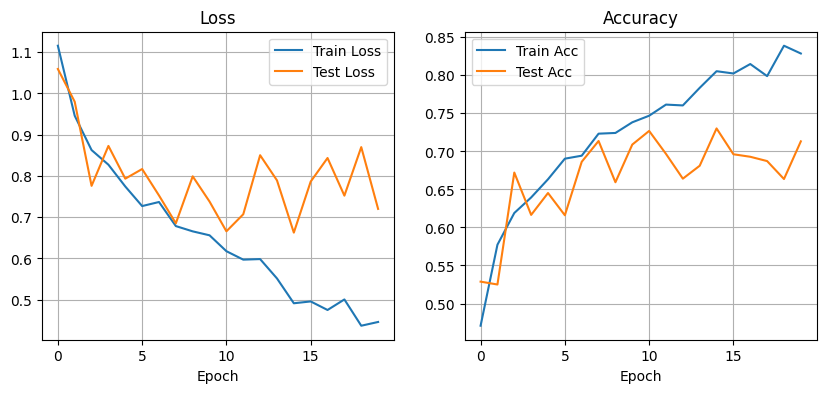

Pred: [2 2 1 2 1]
True: [2 2 0 2 1]
Confusion Matrix:
 [[451  71  58  34]
 [ 50 360  84  17]
 [ 42  50 351  41]
 [ 71  26  64 350]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73       614
           1       0.71      0.70      0.71       511
           2       0.63      0.73      0.67       484
           3       0.79      0.68      0.73       511

    accuracy                           0.71      2120
   macro avg       0.72      0.71      0.71      2120
weighted avg       0.72      0.71      0.71      2120


Accuracy: 0.7132





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (6779, 100)
y shape: (6779,)
env_ids shape: (6779,)


X_data shape: (6779, 1, 100)


X_train: torch.Size([5084, 1, 100])
X_test : torch.Size([1695, 1, 100])
y_train: torch.Size([5084])
y_test : torch.Size([1695])


Epoch [1/20] Train Loss: 0.7882, Train Acc: 0.6798 | Test Loss: 0.5962, Test Acc: 0.7599
Epoch [2/20] Train Loss: 0.6675, Tra

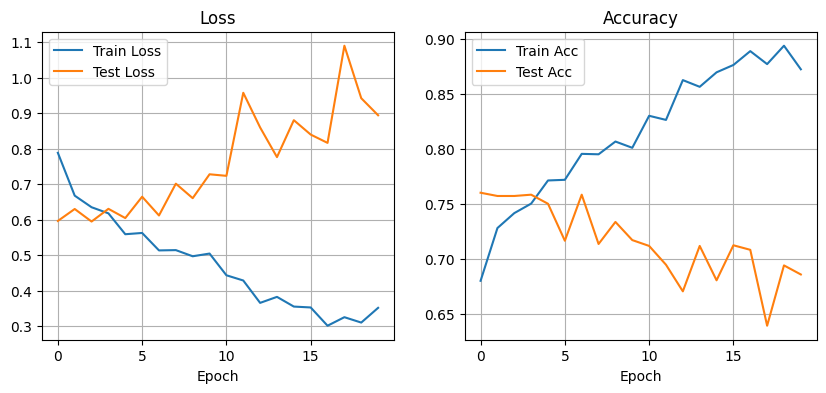

Pred: [0 0 0 0 1]
True: [0 0 0 0 0]
Confusion Matrix:
 [[391  42  35  23]
 [ 56 273  61  18]
 [ 52  39 257  39]
 [ 99  18  51 241]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.80      0.72       491
           1       0.73      0.67      0.70       408
           2       0.64      0.66      0.65       387
           3       0.75      0.59      0.66       409

    accuracy                           0.69      1695
   macro avg       0.69      0.68      0.68      1695
weighted avg       0.69      0.69      0.68      1695


Accuracy: 0.6855





--- WINDOW_SIZE=500, STRIDE=40 ---

X shape: (8277, 500)
y shape: (8277,)
env_ids shape: (8277,)


X_data shape: (8277, 1, 500)


X_train: torch.Size([6207, 1, 500])
X_test : torch.Size([2070, 1, 500])
y_train: torch.Size([6207])
y_test : torch.Size([2070])


Epoch [1/20] Train Loss: 0.2617, Train Acc: 0.9085 | Test Loss: 0.1912, Test Acc: 0.9367
Epoch [2/20] Train Loss: 0.1401, Tra

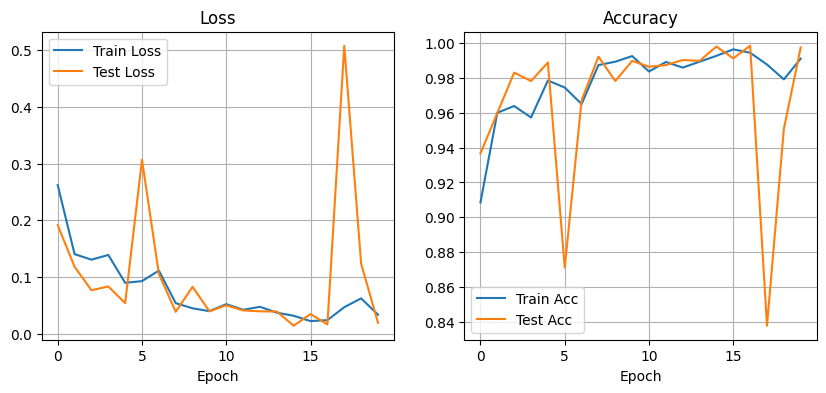

Pred: [1 2 1 0 2]
True: [1 2 1 0 2]
Confusion Matrix:
 [[601   1   0   0]
 [  2 497   0   0]
 [  0   0 471   0]
 [  2   0   0 496]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       602
           1       1.00      1.00      1.00       499
           2       1.00      1.00      1.00       471
           3       1.00      1.00      1.00       498

    accuracy                           1.00      2070
   macro avg       1.00      1.00      1.00      2070
weighted avg       1.00      1.00      1.00      2070


Accuracy: 0.9976





--- WINDOW_SIZE=500, STRIDE=50 ---

X shape: (6619, 500)
y shape: (6619,)
env_ids shape: (6619,)


X_data shape: (6619, 1, 500)


X_train: torch.Size([4964, 1, 500])
X_test : torch.Size([1655, 1, 500])
y_train: torch.Size([4964])
y_test : torch.Size([1655])


Epoch [1/20] Train Loss: 0.4924, Train Acc: 0.8290 | Test Loss: 0.6130, Test Acc: 0.7843
Epoch [2/20] Train Loss: 0.2527, Tra

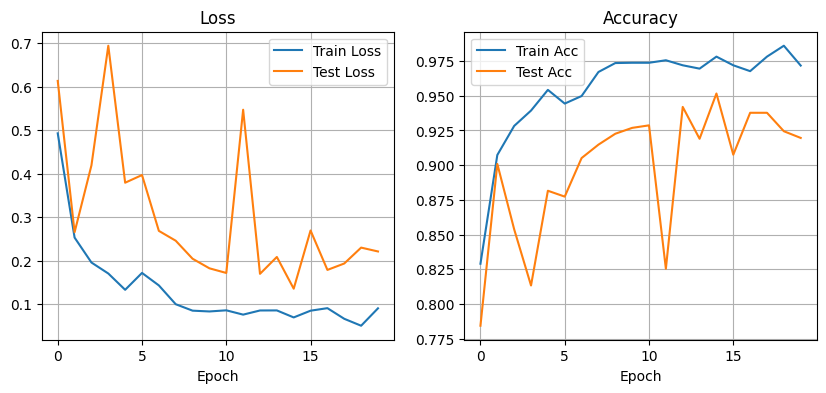

Pred: [1 3 0 3 1]
True: [1 3 0 3 1]
Confusion Matrix:
 [[442   2  15  22]
 [ 10 344  26  18]
 [  1   7 347  22]
 [  5   1   4 389]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.94       481
           1       0.97      0.86      0.91       398
           2       0.89      0.92      0.90       377
           3       0.86      0.97      0.92       399

    accuracy                           0.92      1655
   macro avg       0.92      0.92      0.92      1655
weighted avg       0.92      0.92      0.92      1655


Accuracy: 0.9196





--- WINDOW_SIZE=1000, STRIDE=40 ---

X shape: (8023, 1000)
y shape: (8023,)
env_ids shape: (8023,)


X_data shape: (8023, 1, 1000)


X_train: torch.Size([6017, 1, 1000])
X_test : torch.Size([2006, 1, 1000])
y_train: torch.Size([6017])
y_test : torch.Size([2006])


Epoch [1/20] Train Loss: 0.0122, Train Acc: 0.9982 | Test Loss: 0.0049, Test Acc: 1.0000
Epoch [2/20] Train Loss: 0.0177

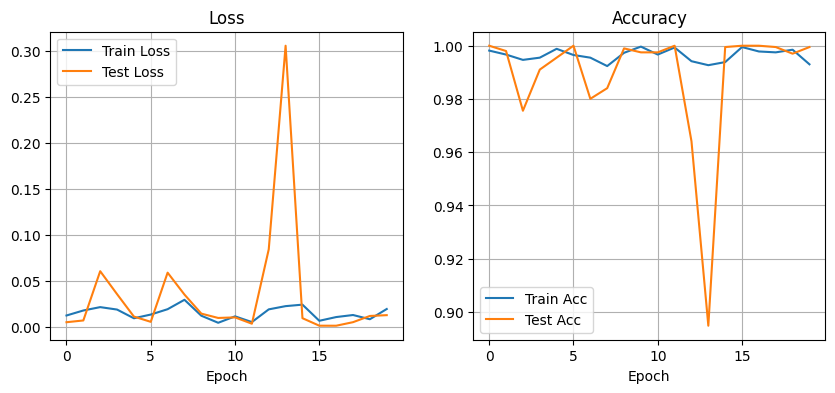

Pred: [2 1 1 2 1]
True: [2 1 1 2 1]
Confusion Matrix:
 [[586   0   0   0]
 [  0 482   0   0]
 [  0   0 454   1]
 [  0   0   0 483]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       586
           1       1.00      1.00      1.00       482
           2       1.00      1.00      1.00       455
           3       1.00      1.00      1.00       483

    accuracy                           1.00      2006
   macro avg       1.00      1.00      1.00      2006
weighted avg       1.00      1.00      1.00      2006


Accuracy: 0.9995





--- WINDOW_SIZE=1000, STRIDE=50 ---

X shape: (6419, 1000)
y shape: (6419,)
env_ids shape: (6419,)


X_data shape: (6419, 1, 1000)


X_train: torch.Size([4814, 1, 1000])
X_test : torch.Size([1605, 1, 1000])
y_train: torch.Size([4814])
y_test : torch.Size([1605])


Epoch [1/20] Train Loss: 0.1103, Train Acc: 0.9614 | Test Loss: 0.1308, Test Acc: 0.9458
Epoch [2/20] Train Loss: 0.0818

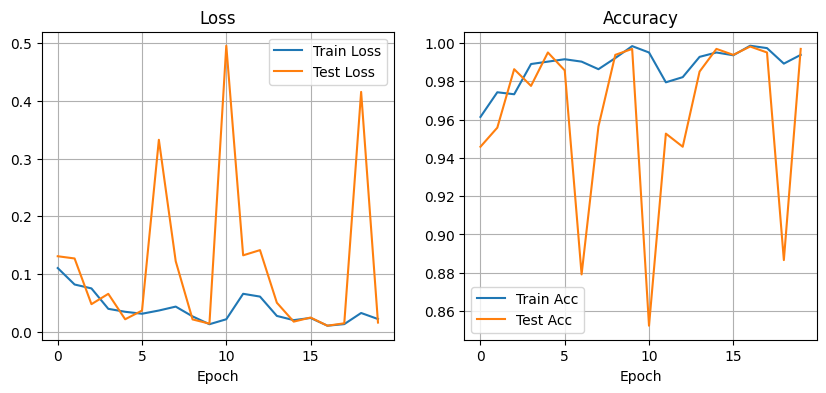

Pred: [3 1 0 3 3]
True: [3 1 0 3 3]
Confusion Matrix:
 [[467   2   0   0]
 [  0 385   0   1]
 [  0   2 362   0]
 [  0   0   0 386]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       469
           1       0.99      1.00      0.99       386
           2       1.00      0.99      1.00       364
           3       1.00      1.00      1.00       386

    accuracy                           1.00      1605
   macro avg       1.00      1.00      1.00      1605
weighted avg       1.00      1.00      1.00      1605


Accuracy: 0.9969






In [345]:
# ===========================
# version 1: random split
# ===========================

results_random = []

print("\n=== Version 1: random split ===\n")

for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, env_files=env_files, device_to_label=device_to_label)

            train_loader_r, test_loader_r, X_test_r_tensor, y_test_r = random_split(X_data, y)

            train_and_evaluate(model, train_loader_r, test_loader_r, criterion, optimizer, device, num_epochs)

            predict(model, X_test_r_tensor, y_test_r, device)
            
            acc = compute_confusion_matrix(model, test_loader_r, device)
            
            results_random.append({
            "window": window_size,
            "stride": stride,
            "acc": acc
            })

            print("\n\n")


=== Version 2: env-based split ===


--- WINDOW_SIZE=100, STRIDE=40 ---

X shape: (8477, 100)
y shape: (8477,)
env_ids shape: (8477,)


X_data shape: (8477, 1, 100)


Train envs: [0, 1, 2, 3, 4]
Test env : 2


X_train: torch.Size([8477, 1, 100])
X_test : torch.Size([1919, 1, 100])
y_train: torch.Size([8477])
y_test : torch.Size([1919])


Epoch [1/20] Train Loss: 0.9565, Train Acc: 0.7189 | Test Loss: 0.6140, Test Acc: 0.7686
Epoch [2/20] Train Loss: 0.5533, Train Acc: 0.7793 | Test Loss: 0.5166, Test Acc: 0.8098
Epoch [3/20] Train Loss: 0.4875, Train Acc: 0.8120 | Test Loss: 0.4556, Test Acc: 0.8218
Epoch [4/20] Train Loss: 0.4297, Train Acc: 0.8292 | Test Loss: 0.4372, Test Acc: 0.8364
Epoch [5/20] Train Loss: 0.3737, Train Acc: 0.8579 | Test Loss: 0.3953, Test Acc: 0.8504
Epoch [6/20] Train Loss: 0.3582, Train Acc: 0.8629 | Test Loss: 0.2632, Test Acc: 0.9130
Epoch [7/20] Train Loss: 0.3381, Train Acc: 0.8741 | Test Loss: 0.3141, Test Acc: 0.8791
Epoch [8/20] Train Loss: 0.3074, Tra

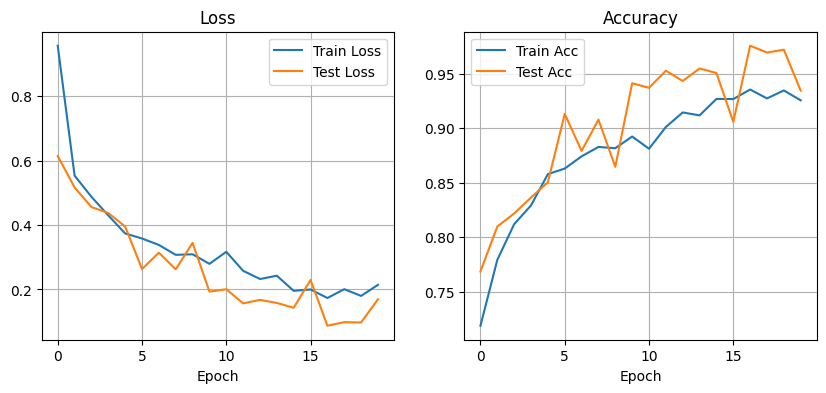

Pred: [0 0 0 0 0]
True: [0 0 0 0 0]
Confusion Matrix:
 [[476  28   7   3]
 [  0 355   0   2]
 [ 13  16 572   5]
 [ 45   7   0 390]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       514
           1       0.87      0.99      0.93       357
           2       0.99      0.94      0.97       606
           3       0.97      0.88      0.93       442

    accuracy                           0.93      1919
   macro avg       0.93      0.94      0.93      1919
weighted avg       0.94      0.93      0.93      1919


Accuracy: 0.9343





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (6779, 100)
y shape: (6779,)
env_ids shape: (6779,)


X_data shape: (6779, 1, 100)


Train envs: [0, 1, 2, 3, 4]
Test env : 2


X_train: torch.Size([6779, 1, 100])
X_test : torch.Size([1535, 1, 100])
y_train: torch.Size([6779])
y_test : torch.Size([1535])


Epoch [1/20] Train Loss: 0.6814, Train Acc: 0.7643 | Test Loss: 0.5635, Test Acc: 

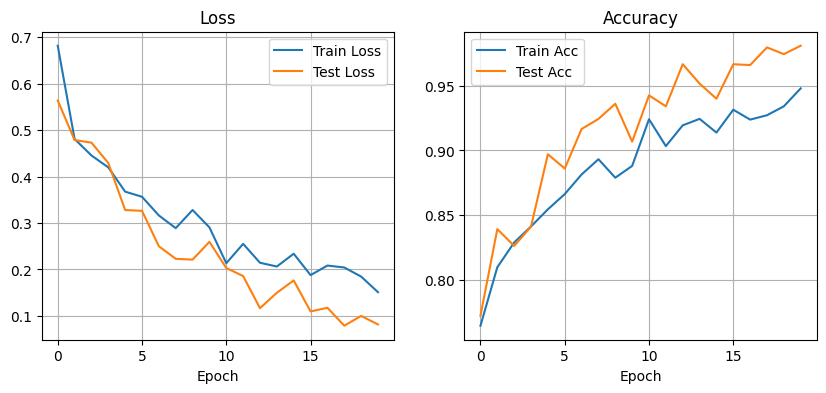

Pred: [0 0 0 0 0]
True: [0 0 0 0 0]
Confusion Matrix:
 [[399  12   0   0]
 [  0 283   2   0]
 [  1   1 483   0]
 [ 13   0   0 341]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       411
           1       0.96      0.99      0.97       285
           2       1.00      1.00      1.00       485
           3       1.00      0.96      0.98       354

    accuracy                           0.98      1535
   macro avg       0.98      0.98      0.98      1535
weighted avg       0.98      0.98      0.98      1535


Accuracy: 0.9811





--- WINDOW_SIZE=500, STRIDE=40 ---

X shape: (8277, 500)
y shape: (8277,)
env_ids shape: (8277,)


X_data shape: (8277, 1, 500)


Train envs: [0, 1, 2, 3, 4]
Test env : 2


X_train: torch.Size([8277, 1, 500])
X_test : torch.Size([1879, 1, 500])
y_train: torch.Size([8277])
y_test : torch.Size([1879])


Epoch [1/20] Train Loss: 0.0741, Train Acc: 0.9775 | Test Loss: 0.0250, Test Acc: 

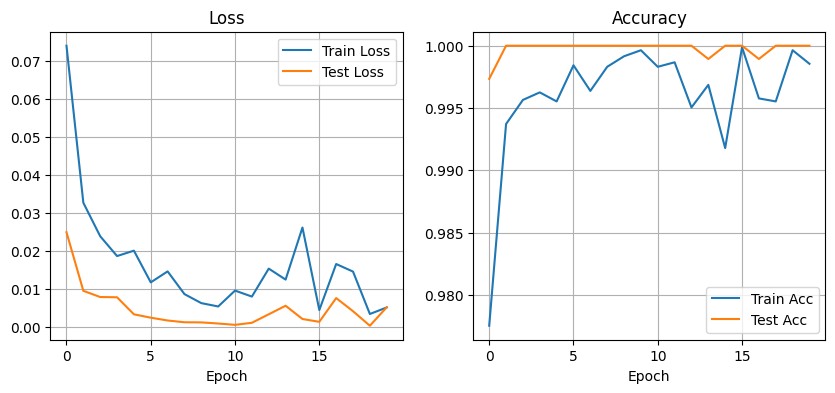

Pred: [0 0 0 0 0]
True: [0 0 0 0 0]
Confusion Matrix:
 [[504   0   0   0]
 [  0 347   0   0]
 [  0   0 596   0]
 [  0   0   0 432]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       504
           1       1.00      1.00      1.00       347
           2       1.00      1.00      1.00       596
           3       1.00      1.00      1.00       432

    accuracy                           1.00      1879
   macro avg       1.00      1.00      1.00      1879
weighted avg       1.00      1.00      1.00      1879


Accuracy: 1.0000





--- WINDOW_SIZE=500, STRIDE=50 ---

X shape: (6619, 500)
y shape: (6619,)
env_ids shape: (6619,)


X_data shape: (6619, 1, 500)


Train envs: [0, 1, 2, 3, 4]
Test env : 2


X_train: torch.Size([6619, 1, 500])
X_test : torch.Size([1503, 1, 500])
y_train: torch.Size([6619])
y_test : torch.Size([1503])


Epoch [1/20] Train Loss: 0.1627, Train Acc: 0.9408 | Test Loss: 1.0967, Test Acc: 

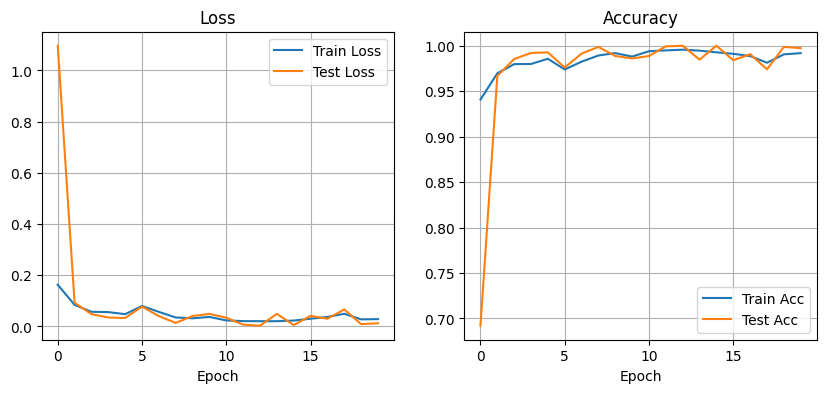

Pred: [0 0 0 0 0]
True: [0 0 0 0 0]
Confusion Matrix:
 [[403   0   0   0]
 [  0 277   0   0]
 [  0   1 476   0]
 [  0   3   0 343]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       403
           1       0.99      1.00      0.99       277
           2       1.00      1.00      1.00       477
           3       1.00      0.99      1.00       346

    accuracy                           1.00      1503
   macro avg       1.00      1.00      1.00      1503
weighted avg       1.00      1.00      1.00      1503


Accuracy: 0.9973





--- WINDOW_SIZE=1000, STRIDE=40 ---

X shape: (8023, 1000)
y shape: (8023,)
env_ids shape: (8023,)


X_data shape: (8023, 1, 1000)


Train envs: [0, 1, 2, 3, 4]
Test env : 2


X_train: torch.Size([8023, 1, 1000])
X_test : torch.Size([1829, 1, 1000])
y_train: torch.Size([8023])
y_test : torch.Size([1829])


Epoch [1/20] Train Loss: 0.0019, Train Acc: 0.9999 | Test Loss: 0.0002, Test 

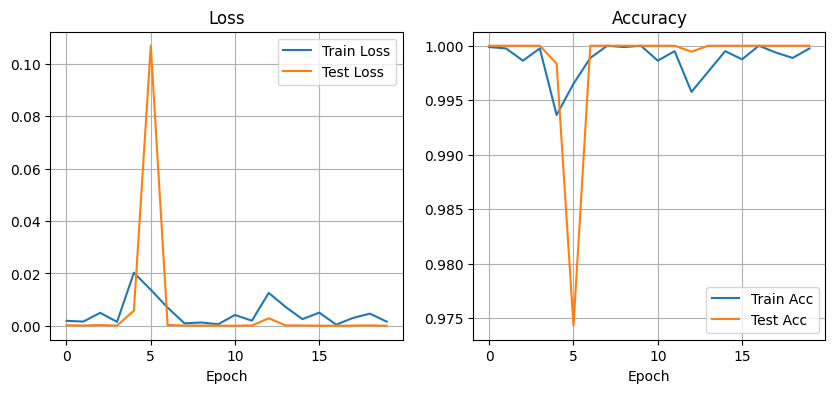

Pred: [0 0 0 0 0]
True: [0 0 0 0 0]
Confusion Matrix:
 [[492   0   0   0]
 [  0 334   0   0]
 [  0   0 583   0]
 [  0   0   0 420]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       492
           1       1.00      1.00      1.00       334
           2       1.00      1.00      1.00       583
           3       1.00      1.00      1.00       420

    accuracy                           1.00      1829
   macro avg       1.00      1.00      1.00      1829
weighted avg       1.00      1.00      1.00      1829


Accuracy: 1.0000





--- WINDOW_SIZE=1000, STRIDE=50 ---

X shape: (6419, 1000)
y shape: (6419,)
env_ids shape: (6419,)


X_data shape: (6419, 1, 1000)


Train envs: [0, 1, 2, 3, 4]
Test env : 2


X_train: torch.Size([6419, 1, 1000])
X_test : torch.Size([1463, 1, 1000])
y_train: torch.Size([6419])
y_test : torch.Size([1463])


Epoch [1/20] Train Loss: 0.0403, Train Acc: 0.9858 | Test Loss: 0.1003, Test 

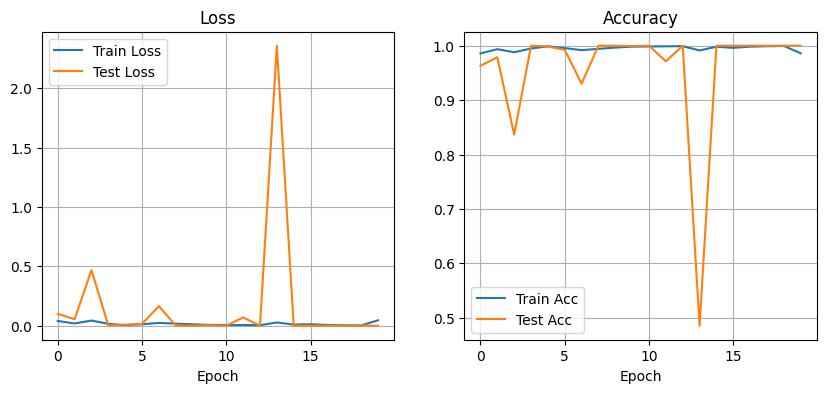

Pred: [0 0 0 0 0]
True: [0 0 0 0 0]
Confusion Matrix:
 [[393   0   0   0]
 [  0 267   0   0]
 [  0   0 467   0]
 [  0   0   0 336]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       393
           1       1.00      1.00      1.00       267
           2       1.00      1.00      1.00       467
           3       1.00      1.00      1.00       336

    accuracy                           1.00      1463
   macro avg       1.00      1.00      1.00      1463
weighted avg       1.00      1.00      1.00      1463


Accuracy: 1.0000






In [346]:
# ===========================
# version 2: env-based split
# ===========================
results_env = []

print("\n=== Version 2: env-based split ===\n")
for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, env_files=env_files, device_to_label=device_to_label)

            train_loader_e, test_loader_e, X_test_e_tensor, y_test_e = env_based_split(X_data, y, env_ids)

            train_and_evaluate(model, train_loader_e, test_loader_e, criterion, optimizer, device, num_epochs)

            predict(model, X_test_e_tensor, y_test_e, device)

            acc = compute_confusion_matrix(model, test_loader_e, device)

            results_env.append({
            "window": window_size,
            "stride": stride,
            "acc": acc
            })
            print("\n\n")

In [347]:
df_results_ran = pd.DataFrame(results_random)
print("\n=== Random Split Accuracy Results ===\n")
print(f"{df_results_ran.to_string(index=False)}\n")

df_results_env = pd.DataFrame(results_env)
print("\n=== Env-based Split Accuracy Results ===\n")
print(f"{df_results_env.to_string(index=False)}\n")


=== Random Split Accuracy Results ===

 window  stride    acc
    100      40 0.7132
    100      50 0.6855
    500      40 0.9976
    500      50 0.9196
   1000      40 0.9995
   1000      50 0.9969


=== Env-based Split Accuracy Results ===

 window  stride    acc
    100      40 0.9343
    100      50 0.9811
    500      40 1.0000
    500      50 0.9973
   1000      40 1.0000
   1000      50 1.0000

